## Frequency Table

In [1]:
# ======================================================
# IMPORT LIBRARIES
# ======================================================
import pandas as pd
import numpy as np
from io import StringIO

# ======================================================
# DATASET
# ======================================================
data = """
ID Gender StudyHoursPerWeek ClassAttendancePercent PreviousGPA FinalExamScore
1 0 7.3 82 3.4 78
2 1 12.4 93 2.78 95
3 1 12.3 93 3.11 95
4 0 11.9 84 3.6 95
5 1 9.3 95 2.52 91
6 1 9.5 98 2.54 88
7 1 10.4 90 2.77 93
8 1 10.6 91 2.07 88
9 1 10.5 73 2.93 89
10 1 12.3 89 3.31 95
11 0 9.6 93 3.03 95
12 0 11.6 98 2.36 86
13 0 10.9 82 2.1 81
14 0 6.6 87 3.09 82
15 0 7.3 94 3.28 95
16 1 11.7 80 3.47 95
17 1 11.5 90 2.89 95
18 1 13.2 65 2.3 84
19 1 3.3 89 3.08 71
20 0 11.8 74 2.64 95
21 0 2.8 73 2.3 69
22 0 9.8 83 3.47 91
23 0 2.6 82 2.29 63
24 0 14 85 3.36 95
25 1 7.4 67 2.56 81
26 0 16.5 77 3.15 95
27 0 10.6 98 3.25 95
28 0 12.5 85 3.27 95
29 0 11.7 78 2.78 95
30 1 15.4 90 3.29 95
31 1 9.9 83 2.29 83
32 0 6.6 91 2.16 73
33 0 6.4 83 2.58 75
34 0 7.2 98 3.23 83
35 1 10.2 86 3.15 81
36 0 11.1 87 3.1 95
37 1 9.2 72 3.13 83
38 0 10.5 78 2.59 78
39 0 14.7 92 3.24 95
40 0 4.7 79 2.58 63
41 0 8.3 92 2.44 76
42 0 13.1 73 3.09 94
43 0 6.8 84 2.65 83
44 1 13.1 91 2.4 95
45 0 8.7 86 2.91 83
46 1 8.2 82 3.21 93
47 1 9.4 91 2.87 87
48 1 10.5 97 2.6 90
49 0 9 88 2.97 83
50 0 14.6 96 3.5 95
"""

df = pd.read_csv(StringIO(data), sep=r"\s+")

# ======================================================
# FREQUENCY TABLE FUNCTION
# ======================================================
def frequency_table(series, bins=6):

    # categorical variable
    if series.nunique() <= 10:
        table = series.value_counts().sort_index().reset_index()
        table.columns = ["Value", "Frequency"]
        table["Percentage (%)"] = (table["Frequency"]/len(series)*100).round(2)
        return table

    # numerical variable
    categories = pd.cut(series, bins=bins, include_lowest=True)
    freq = categories.value_counts().sort_index()

    table = pd.DataFrame({
        "Class Interval":freq.index.astype(str),
        "Frequency":freq.values,
        "Percentage (%)":(freq.values/len(series)*100).round(2),
        "Cumulative Frequency":np.cumsum(freq.values)
    })
    return table

# ======================================================
# FREQUENCY TABLES FOR ALL VARIABLES
# ======================================================
for column in df.columns:
    print("\n===================================")
    print(f"Frequency Table for {column}")
    display(frequency_table(df[column]))


Frequency Table for ID


,Class Interval,Frequency,Percentage (%),Cumulative Frequency
0,"(0.95, 9.167]",9,18.0,9
1,"(9.167, 17.333]",8,16.0,17
2,"(17.333, 25.5]",8,16.0,25
3,"(25.5, 33.667]",8,16.0,33
4,"(33.667, 41.833]",8,16.0,41
5,"(41.833, 50.0]",9,18.0,50



Frequency Table for Gender


,Value,Frequency,Percentage (%)
0,0,29,58.0
1,1,21,42.0



Frequency Table for StudyHoursPerWeek


...

,Class Interval,Frequency,Percentage (%),Cumulative Frequency
0,"(64.966, 70.5]",2,4.0,2
1,"(70.5, 76.0]",5,10.0,7
2,"(76.0, 81.5]",5,10.0,12
3,"(81.5, 87.0]",15,30.0,27
4,"(87.0, 92.5]",12,24.0,39
5,"(92.5, 98.0]",11,22.0,50



Frequency Table for PreviousGPA


,Class Interval,Frequency,Percentage (%),Cumulative Frequency
0,"(2.067, 2.325]",7,14.0,7
1,"(2.325, 2.58]",8,16.0,15
2,"(2.58, 2.835]",7,14.0,22
3,"(2.835, 3.09]",9,18.0,31
4,"(3.09, 3.345]",13,26.0,44
5,"(3.345, 3.6]",6,12.0,50



Frequency Table for FinalExamScore


,Class Interval,Frequency,Percentage (%),Cumulative Frequency
0,"(62.967000000000006, 68.333]",2,4.0,2
1,"(68.333, 73.667]",3,6.0,5
2,"(73.667, 79.0]",4,8.0,9
3,"(79.0, 84.333]",11,22.0,20
4,"(84.333, 89.667]",5,10.0,25
5,"(89.667, 95.0]",25,50.0,50


## Histogram, Frequency Polygon and Ogive curve

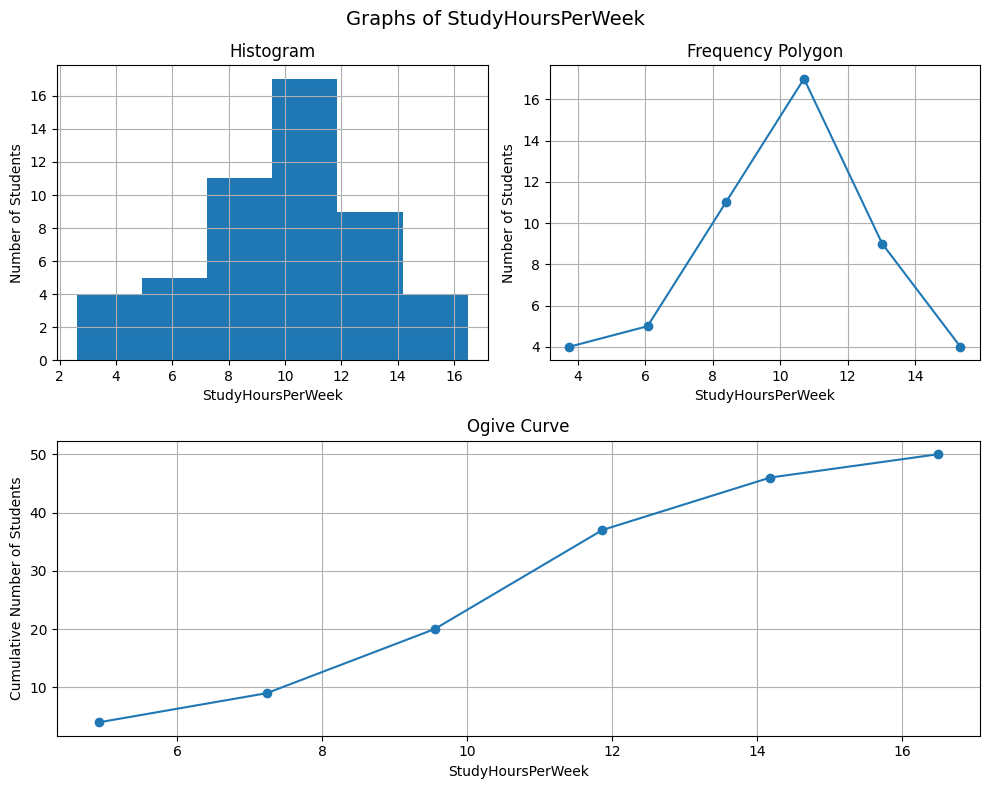

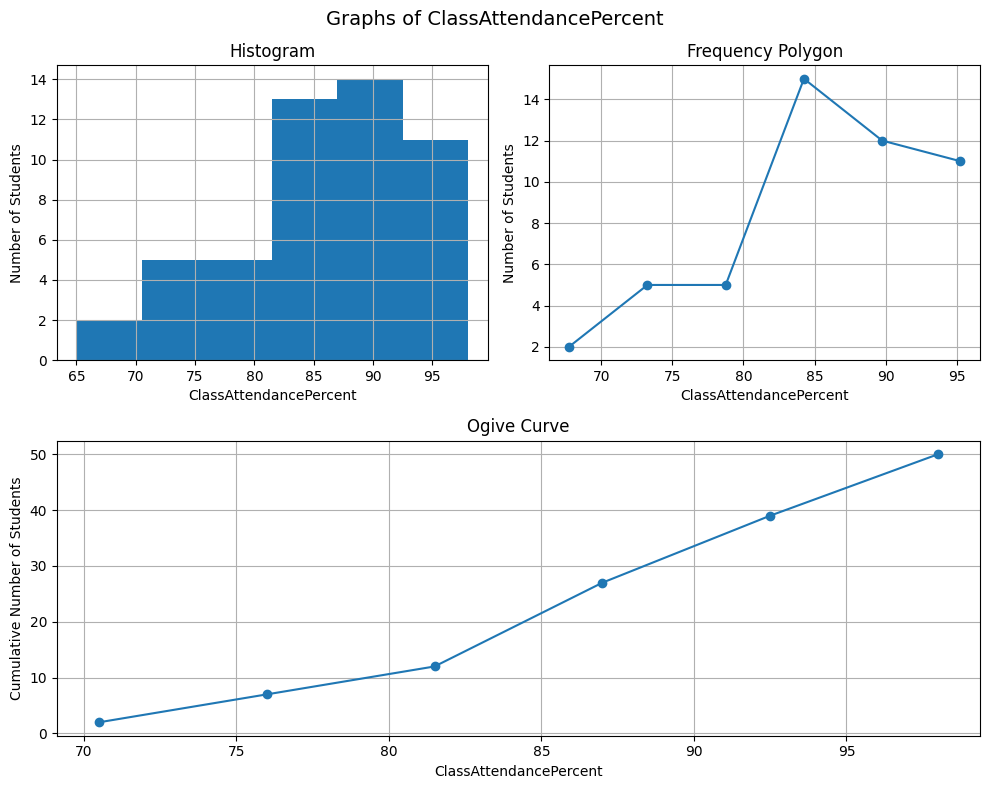

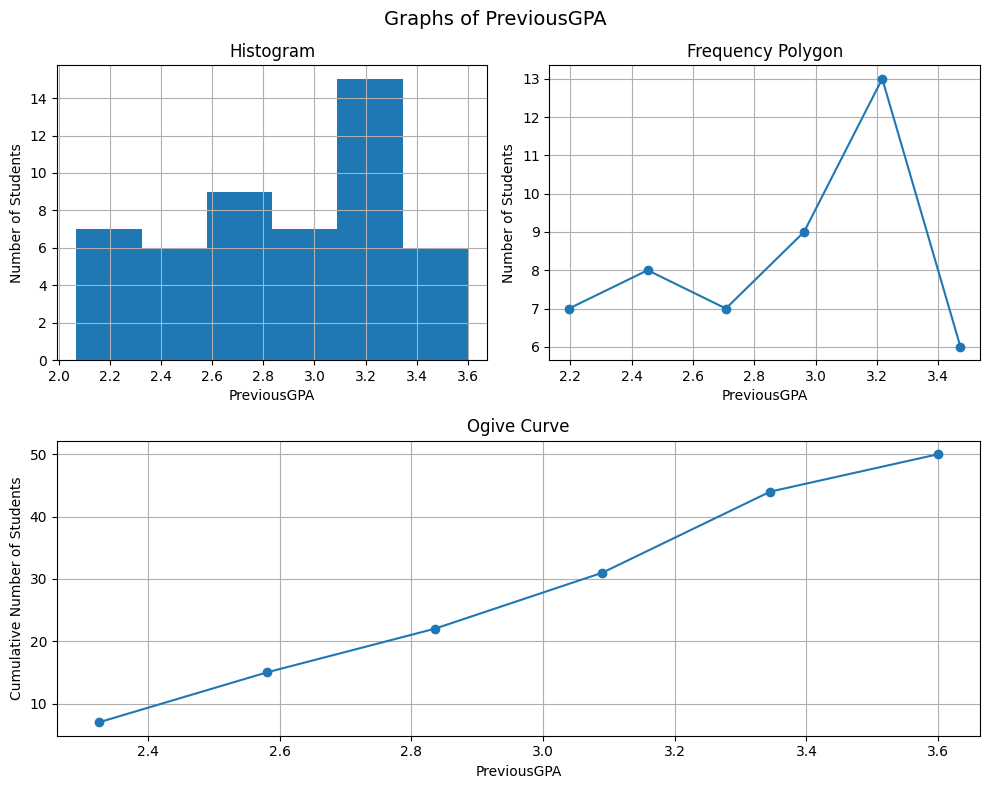

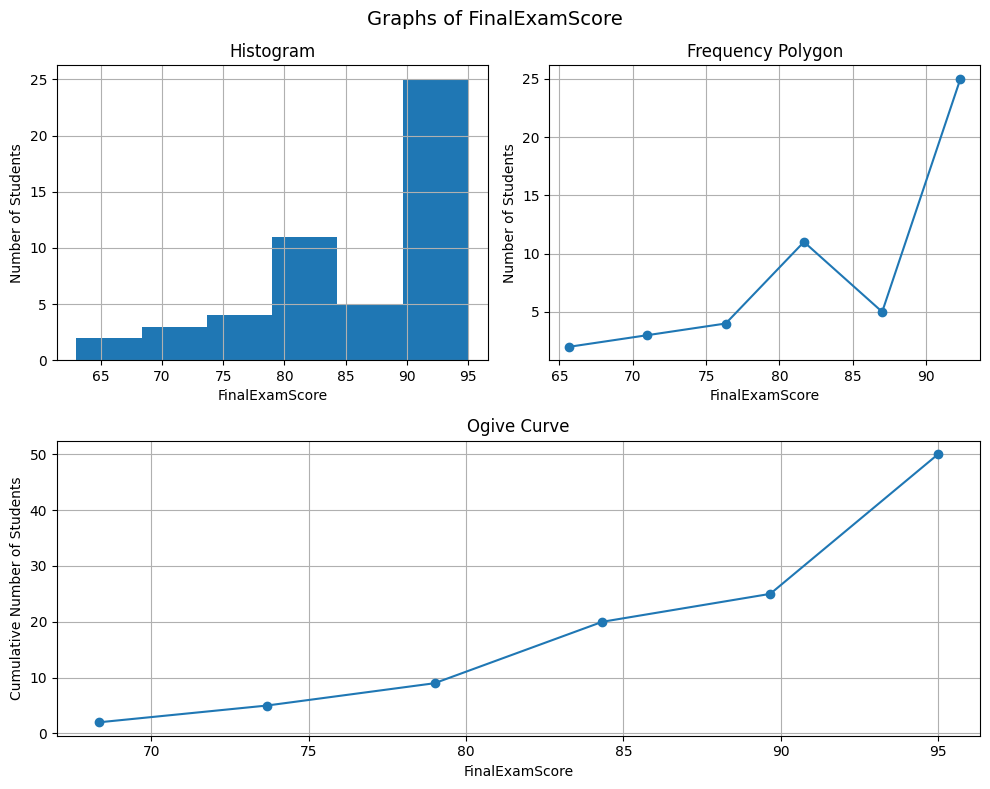

In [7]:
# =====================================
# 1. Import Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# =====================================
# 2. DATASET
# =====================================
data = """
ID Gender StudyHoursPerWeek ClassAttendancePercent PreviousGPA FinalExamScore
1 0 7.3 82 3.4 78
2 1 12.4 93 2.78 95
3 1 12.3 93 3.11 95
4 0 11.9 84 3.6 95
5 1 9.3 95 2.52 91
6 1 9.5 98 2.54 88
7 1 10.4 90 2.77 93
8 1 10.6 91 2.07 88
9 1 10.5 73 2.93 89
10 1 12.3 89 3.31 95
11 0 9.6 93 3.03 95
12 0 11.6 98 2.36 86
13 0 10.9 82 2.1 81
14 0 6.6 87 3.09 82
15 0 7.3 94 3.28 95
16 1 11.7 80 3.47 95
17 1 11.5 90 2.89 95
18 1 13.2 65 2.3 84
19 1 3.3 89 3.08 71
20 0 11.8 74 2.64 95
21 0 2.8 73 2.3 69
22 0 9.8 83 3.47 91
23 0 2.6 82 2.29 63
24 0 14 85 3.36 95
25 1 7.4 67 2.56 81
26 0 16.5 77 3.15 95
27 0 10.6 98 3.25 95
28 0 12.5 85 3.27 95
29 0 11.7 78 2.78 95
30 1 15.4 90 3.29 95
31 1 9.9 83 2.29 83
32 0 6.6 91 2.16 73
33 0 6.4 83 2.58 75
34 0 7.2 98 3.23 83
35 1 10.2 86 3.15 81
36 0 11.1 87 3.1 95
37 1 9.2 72 3.13 83
38 0 10.5 78 2.59 78
39 0 14.7 92 3.24 95
40 0 4.7 79 2.58 63
41 0 8.3 92 2.44 76
42 0 13.1 73 3.09 94
43 0 6.8 84 2.65 83
44 1 13.1 91 2.4 95
45 0 8.7 86 2.91 83
46 1 8.2 82 3.21 93
47 1 9.4 91 2.87 87
48 1 10.5 97 2.6 90
49 0 9 88 2.97 83
50 0 14.6 96 3.5 95
"""

df = pd.read_csv(StringIO(data), sep=r"\s+")

# =====================================
# Variables
# =====================================
variables = [
    "StudyHoursPerWeek",
    "ClassAttendancePercent",
    "PreviousGPA",
    "FinalExamScore"
]

# =====================================
# Graph Function (NEW LAYOUT)
# =====================================
def draw_graphs(series, var_name, bins=6):

    series = series.dropna()

    categories = pd.cut(series, bins=bins, include_lowest=True)
    freq = categories.value_counts().sort_index()
    cum_freq = freq.cumsum()

    midpoints = [interval.mid for interval in freq.index]
    upper_bounds = [interval.right for interval in freq.index]

    # Create layout
    fig = plt.figure(figsize=(10,8))

    # Histogram (top left)
    ax1 = plt.subplot2grid((2,2),(0,0))
    ax1.hist(series, bins=bins)
    ax1.set_title("Histogram")
    ax1.set_xlabel(var_name)
    ax1.set_ylabel("Number of Students")
    ax1.grid(True)

    # Frequency Polygon (top right)
    ax2 = plt.subplot2grid((2,2),(0,1))
    ax2.plot(midpoints, freq.values, marker='o')
    ax2.set_title("Frequency Polygon")
    ax2.set_xlabel(var_name)
    ax2.set_ylabel("Number of Students")
    ax2.grid(True)

    # Ogive Curve (bottom centered)
    ax3 = plt.subplot2grid((2,2),(1,0), colspan=2)
    ax3.plot(upper_bounds, cum_freq.values, marker='o')
    ax3.set_title("Ogive Curve")
    ax3.set_xlabel(var_name)
    ax3.set_ylabel("Cumulative Number of Students")
    ax3.grid(True)

    plt.suptitle(f"Graphs of {var_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# =====================================
# Generate Graphs
# =====================================
for var in variables:
    draw_graphs(df[var], var)